Notebook

In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests
from PIL import Image
from io import BytesIO
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.imagenet_utils import decode_predictions

In [18]:
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0, InceptionV3, Xception, VGG16, VGG19, DenseNet121, DenseNet169, NASNetMobile
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg19_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.nasnet import preprocess_input as nasnet_preprocess


models = {
    "MobileNetV2": (MobileNetV2(weights='imagenet'), mobilenet_preprocess),
    "ResNet50": (ResNet50(weights='imagenet'), resnet_preprocess),
    "EfficientNetB0": (EfficientNetB0(weights='imagenet'), efficientnet_preprocess),
    "InceptionV3": (InceptionV3(weights='imagenet'), inception_preprocess),
    "Xception": (Xception(weights='imagenet'), xception_preprocess),
    "VGG16": (VGG16(weights='imagenet'), vgg16_preprocess),
    "VGG19": (VGG19(weights='imagenet'), vgg19_preprocess),
    "DenseNet121": (DenseNet121(weights='imagenet'), densenet_preprocess),
    "DenseNet169": (DenseNet169(weights='imagenet'), densenet_preprocess),
    "NASNetMobile": (NASNetMobile(weights='imagenet'), nasnet_preprocess)
}

# # Load models
# models = {
#     "MobileNetV2": (MobileNetV2(weights='imagenet'), mobilenet_preprocess),
#     "ResNet50": (ResNet50(weights='imagenet'), resnet_preprocess),
#     "EfficientNetB0": (EfficientNetB0(weights='imagenet'), efficientnet_preprocess)
# }

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
574710816/574710816 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
33188688/33188688 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
58541896/58541896 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
24227760/24227760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [51]:
image_url

'https://t3.ftcdn.net/jpg/01/35/29/82/360_F_135298296_8IF6Jd3R2gCKRlEioI9K4r5kKWQyfzHd.jpghttps://www.webbox.co.uk/wp-content/uploads/2019/04/shutterstock_1095001973.jpg'

In [44]:
response = requests.get("https://upload.wikimedia.org/wikipedia/commons/thumb/2/2e/Norton_Motorcycle.jpg/800px-Norton_Motorcycle.jpg")
response
image = Image.open(BytesIO(response.content)).convert("RGB")

In [74]:
# Test images (Replace URLs with different tricky images)
image_urls = [
    # "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQMmKJXF_5S7J3Qak4fE8BjK28orpWZJEYNAA&s",  # Black cat
    # "https://www.harrisfarm.com.au/cdn/shop/products/40715-done.jpg?v=1623908361&width=1946",  # Apple
    # "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRYP-BzAxTWBG1hjvjitvFNZOYGyoSAwhSHDw&s", # Elephant
    # "https://c02.purpledshub.com/uploads/sites/40/2023/08/JI230816Cosmos220-6d9254f-edited-scaled.jpg", #Flower
    # "https://www.tripaneer.com/static/files/images/nn/rs/qi/mh/content.jpg" #motorcycle
    # "https://t3.ftcdn.net/jpg/01/35/29/82/360_F_135298296_8IF6Jd3R2gCKRlEioI9K4r5kKWQyfzHd.jpg" #man riding horse
    "https://www.webbox.co.uk/wp-content/uploads/2019/04/shutterstock_1095001973.jpg" # cat and dog
    # "https://upload.wikimedia.org/wikipedia/commons/2/2c/Rotating_earth_%28large%29.gif"  # Tricky image (GIF, needs conversion)
]

results = []

In [75]:
for image_url in image_urls:
    response = requests.get(image_url)
    image = Image.open(BytesIO(response.content)).convert("RGB")

    row = {"Image URL": image_url}

    for model_name, (model, preprocess) in models.items():
        # Resize image based on model's input requirements
        if model_name in ["InceptionV3", "Xception"]:
            target_size = (299, 299)
        elif model_name == "NASNetMobile":
            target_size = (224, 224) # Use Native Resolution for NASNetMobile
        else:
            target_size = (224, 224)

        image_resized = image.resize(target_size)
        image_array = np.array(image_resized)

        img_batch = np.expand_dims(image_array, axis=0)
        img_batch = preprocess(img_batch)
        predictions = model.predict(img_batch)
        decoded_predictions = decode_predictions(predictions, top=1)[0]
        row[model_name] = f"{decoded_predictions[0][1]} ({decoded_predictions[0][2]:.2f})"

    results.append(row)

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 758ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
                                           Image URL             MobileNetV2  \
0  https://www.webbox.co.uk/wp-content/uploads/20...  German_shepherd (0.73)   

                 ResNet50          EfficientNetB0             InceptionV3  \
0  German_shepherd (0.36)  German_shepherd (0.32)  German_shepherd (0.90)   

                 Xception                   VGG16                   VGG19  \
0  German_shepherd (0.63)  German_shepherd (0.25)  German_shepherd (0.19)   

              DenseNet121             DenseNet169            NASNetMobile  
0  German_shepherd (0.58)  German_shepherd (0.75)  German_shephe

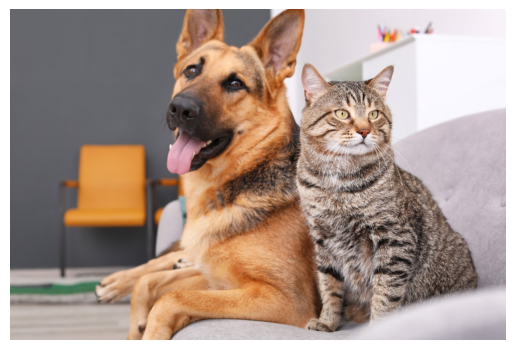

Model Predictions:
- MobileNetV2: German_shepherd (0.73)
- ResNet50: German_shepherd (0.36)
- EfficientNetB0: German_shepherd (0.32)
- InceptionV3: German_shepherd (0.90)
- Xception: German_shepherd (0.63)
- VGG16: German_shepherd (0.25)
- VGG19: German_shepherd (0.19)
- DenseNet121: German_shepherd (0.58)
- DenseNet169: German_shepherd (0.75)
- NASNetMobile: German_shepherd (0.85)




In [76]:
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image
from io import BytesIO

# Function to fetch and display an image
def display_image(url):
    response = requests.get(url)
    image = Image.open(BytesIO(response.content)).convert("RGB")
    plt.imshow(image)
    plt.axis('off')  # Hide axes
    plt.show()

# Iterate through rows of results_df
for index, row in results_df.iterrows():
    # Display the image
    display_image(row['Image URL'])

    # Print model predictions
    print("Model Predictions:")
    for model_name in models.keys():  # Assuming 'models' is defined earlier
        prediction = row[model_name]
        print(f"- {model_name}: {prediction}")
    print("\n") # Add an empty line for separation

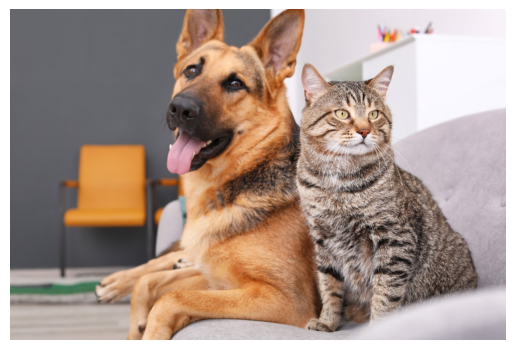

,Model,Prediction
0,MobileNetV2,German_shepherd (0.73)
1,ResNet50,German_shepherd (0.36)
2,EfficientNetB0,German_shepherd (0.32)
3,InceptionV3,German_shepherd (0.90)
4,Xception,German_shepherd (0.63)
5,VGG16,German_shepherd (0.25)
6,VGG19,German_shepherd (0.19)
7,DenseNet121,German_shepherd (0.58)
8,DenseNet169,German_shepherd (0.75)
9,NASNetMobile,German_shepherd (0.85)


In [77]:
import pandas as pd

# ... (Your existing code for image fetching and predictions) ...

# Iterate through rows of results_df
for index, row in results_df.iterrows():
    # Display the image
    display_image(row['Image URL'])

    # Create a DataFrame for predictions
    predictions_df = pd.DataFrame({
        "Model": models.keys(),
        "Prediction": [row[model_name] for model_name in models.keys()]
    })

    # Display the predictions DataFrame
    display(predictions_df)
    print("\n")  # Add an empty line for separation

In [78]:


# # Save results to a PowerPoint file
# ppt = Presentation()
# slide = ppt.slides.add_slide(ppt.slide_layouts[5])

# # Add title
# title = slide.shapes.title
# subtitle = slide.placeholders[1]
# title.text = "Model Comparison on Image Classification"
# subtitle.text = "Using Keras Applications"

# # Add table
# rows, cols = results_df.shape
# left = Inches(0.5)
# top = Inches(2)
# width = Inches(9)
# height = Inches(2 + rows * 0.5)
# table = slide.shapes.add_table(rows+1, cols, left, top, width, height).table

# # Fill header
# for col_idx, col_name in enumerate(results_df.columns):
#     table.cell(0, col_idx).text = col_name

# # Fill data
# for row_idx, row in enumerate(results_df.values, start=1):
#     for col_idx, value in enumerate(row):
#         table.cell(row_idx, col_idx).text = str(value)

# # Save the PowerPoint file
# ppt.save("model_comparison.pptx")
# print("PowerPoint saved as model_comparison.pptx")
